<a href="https://colab.research.google.com/github/malakagunasekara/imageprocessing/blob/main/Q4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from google.colab import files


In [9]:
uploaded = files.upload()
image_name = list(uploaded.keys())[0]

# Read image
img_bgr = cv2.imread(image_name)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)


Saving womanstanding.png to womanstanding.png


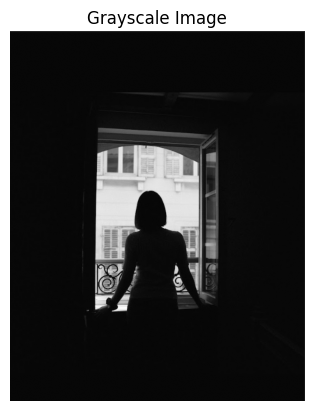

In [10]:
gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)

plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis('off')
plt.show()


Otsu threshold value: 101.0


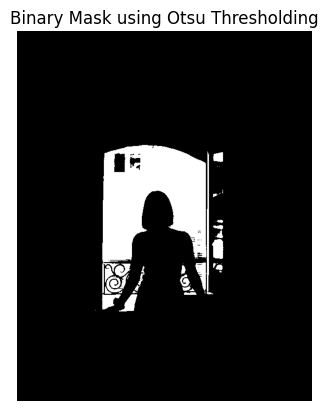

In [11]:
# Apply Otsu thresholding
threshold, mask = cv2.threshold(
    gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU
)

print("Otsu threshold value:", threshold)

plt.imshow(mask, cmap='gray')
plt.title("Binary Mask using Otsu Thresholding")
mask = cv2.bitwise_not(mask)
plt.axis('off')
plt.show()


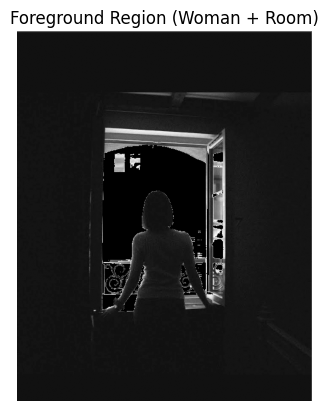

In [12]:
foreground = cv2.bitwise_and(gray, gray, mask=mask)

plt.imshow(foreground, cmap='gray')
plt.title("Foreground Region (Woman + Room)")
plt.axis('off')
plt.show()


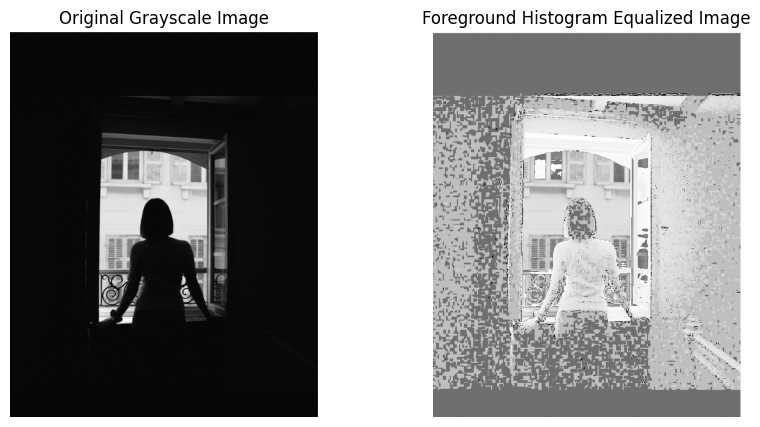

In [13]:
# Histogram equalization
equalized = cv2.equalizeHist(foreground)

# Keep background unchanged
result = gray.copy()
result[mask == 255] = equalized[mask == 255]

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Original Grayscale Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(result, cmap='gray')
plt.title("Foreground Histogram Equalized Image")
plt.axis('off')

plt.show()


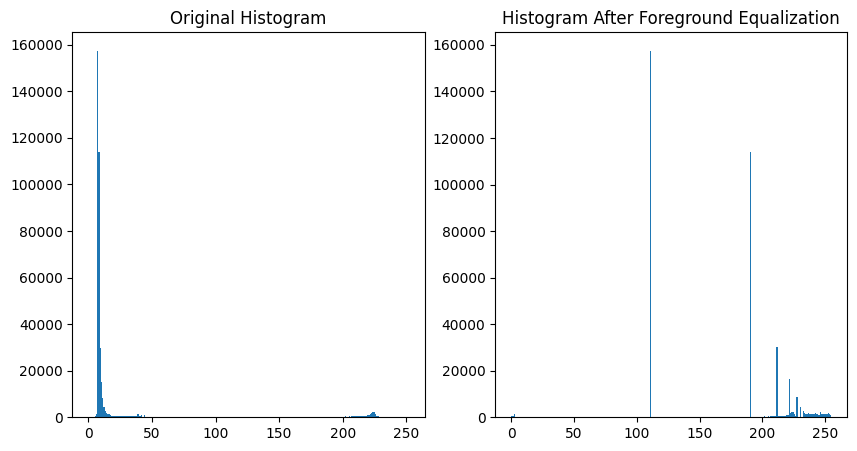

In [14]:
plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.hist(gray.flatten(), bins=256)
plt.title("Original Histogram")

plt.subplot(1,2,2)
plt.hist(result.flatten(), bins=256)
plt.title("Histogram After Foreground Equalization")

plt.show()
